In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import scipy.io as io
import argparse

import src.models.models as models
import src.training.self_supervision as ssl
import src.utils.utils as utils
import src.utils.extractor as extractor

if torch.cuda.is_available():
    dev = "cuda:0"
    torch.set_default_device(dev)
else:
    print(f"{torch.cuda.is_available()}")
    dev = "cpu"

/home/ids/edabier/miniconda3/envs/hsu-env/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/ids/edabier/miniconda3/envs/hsu-env/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may hav

162


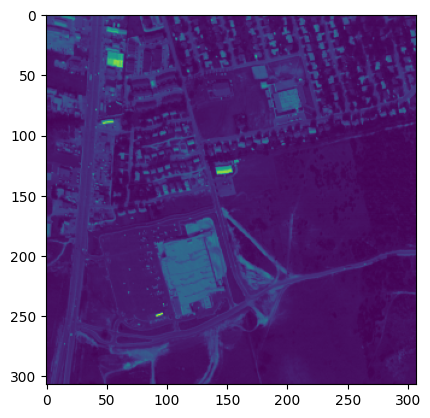

In [2]:
dataset = "urban"
data = io.loadmat(f"datasets/{dataset}.mat")
Y = torch.tensor(data["Y"])
Y = Y.to(torch.float32)
E = torch.tensor(data["E"])
B, c, N = E.shape[0], E.shape[1], Y.shape[1]
print(B)

Y_flat, H = utils.oneD_to_2d(Y)
W = H

patch_size = 5
batch_size = 10

plt.imshow(Y_flat.cpu()[10,:,:])

In [ ]:
loader, _, _ = utils.create_dataloader(dataset, dev=dev, batch_size=1)
mses = torch.zeros(2, 5, device=dev)
sads = torch.zeros(2, 5, device=dev)
model_list = []
nalmu = models.NALMU(B=B, c=c, N=N)
nalmu = nalmu.to(dev)
model_list.append(nalmu)

# RALMU
ralmu = models.RALMU(B=B, c=c, im_size=H)
ralmu = ralmu.to(dev)
model_list.append(ralmu)

"""
Instanciating trainers
"""
for i_model, model in enumerate(model_list):
    model_name = model.__class__.__name__
    e_hat, a_hat, train_losses = ssl.train(model, loader, has_decoder=False, epochs=2, lr=0.001, dev=dev)

    fig = plt.figure()
    plt.plot(train_losses)
    plt.close(fig)
    del e_hat, a_hat
    torch.cuda.empty_cache()

    model.load_state_dict(torch.load(f"/home/ids/edabier/HSU/SS-HSU_benchmark/models/{model_name}_Basic_{dataset}_lr_{0.00001}.pt")["model_state_dict"], strict=False)

    batch = next(iter(loader))
    Y, e_gt, a_gt = batch[0][0], batch[1][0], batch[2][0]
    
    A_init_disp = next(iter(loader))[2].to(torch.float32)
    E_init_disp = torch.ones(next(iter(loader))[1].size(),dtype=torch.float32)
    A_init = torch.ones_like(A_init_disp)
    E_init = torch.ones_like(E_init_disp)

    with torch.no_grad():
        e_hat, a_hat, y_hat = model.forward(Y, E_init=E_init, A_init=A_init)

    if e_hat.dim() == 3:
        e_hat = e_hat.squeeze(0)
    
    a_hat = a_hat.reshape(a_hat.shape[1], int(a_hat.shape[2]**0.5), int(a_hat.shape[2]**0.5))
    a_gt = a_gt.reshape(a_gt.shape[0], int(a_gt.shape[1]**0.5), int(a_gt.shape[1]**0.5))    
    
    # mse, sad = utils.compute_metrics_and_plot(e_hat, e_gt, a_hat, a_gt, name=f"{model_name}_BASIC_{dataset}", use_wandb=False)
    # mses[i_model, 0] = torch.tensor(mse[-1]).item()
    # sads[i_model, 0] = torch.tensor(sad[-1]).item()

    # del e_hat, a_hat, y_hat
    # del A_init, E_init
    # del model
    # torch.cuda.empty_cache()

mean_mses = torch.mean(mses, dim=1)
std_mses = torch.std(mses, dim=1)
mean_sads = torch.mean(sads, dim=1)
std_sads = torch.std(sads, dim=1)
# print(mean_mses, std_mses)

tensor([0., 0.], device='cuda:0') tensor([0., 0.], device='cuda:0')


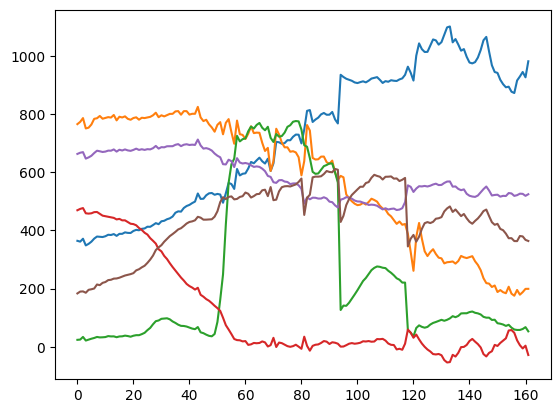

In [3]:
E = extractor.SiVM(Y, c, E)
plt.plot(E[:,:].cpu())

In [4]:
# dataset_full = utils.HSI_dataset(dataset=dataset)
# dataset_patched = utils.HSI_dataset(dataset=dataset, patch_size=patch_size)
# full_loader = DataLoader(dataset_full)
# patched_loader = DataLoader(dataset_patched)

full_loader, _, _ = utils.create_dataloader(dataset, "datasets/", dev, batch_size=batch_size)
# patched_loader, test_loader, B, _ = utils.create_dataloader(dataset, dev, 0.7, patch_size, batch_size=batch_size)

## Models

In [5]:
# """
# MLP: Adam "poly" learning rate policy lr=0.1 * (1-iter/max_iter)**0.99, rate_dropout=0.9
# """
# mlpae = models.MLP_AE(B=B, c=c)
# print("MLP: ", sum(p.numel() for p in mlpae.parameters() if p.requires_grad)/1e6, "M")

# """
# CNN + linear decoder
# """
# cnnlinear = models.CNNAE_linear(B=B, c=c, patch_size=patch_size)
# print("CNN + linear decoder: ", sum(p.numel() for p in cnnlinear.parameters() if p.requires_grad)/1e6, "M")

"""
CNNAEU: epochs=320, lr=0.0003, batch=15
"""
Y_init, e_gt, a_gt = next(iter(full_loader))[0][0], next(iter(full_loader))[1][0], next(iter(full_loader))[2][0]
cnnaeu = models.CNNAEU(B=B, c =c)
cnnaeu = models.init_decoder_weights(cnnaeu, Y_init, c, 11)
print("CNNAEU: ", sum(p.numel() for p in cnnaeu.parameters() if p.requires_grad)/1e6, "M")

"""
Deep Trans: patch_size=5, a*L_RE + b*L_SAD (a ≃ 1e5*b), epochs=200, lr=6-9e-3 -20% every 15epochs, 
weight decay rate 4e-5 (inside adamw)
"""
Y_trans = Y_flat[:,:(Y_flat.shape[1]//patch_size)*patch_size,:(Y_flat.shape[1]//patch_size)*patch_size]
deep_trans = models.Transformer_AE(B=B, c=c, patch_size=patch_size, im_size=Y_trans.shape[1], dim=200)
deep_trans = models.init_decoder_weights(deep_trans, Y_init, c)
print("Deep trans: ", sum(p.numel() for p in deep_trans.parameters() if p.requires_grad)/1e6, "M")

"""
UnDIP
"""
undip = models.UnDIP(B=B, c=c)
print("UnDIP: ", sum(p.numel() for p in undip.parameters() if p.requires_grad)/1e6, "M")

"""
NALMU
"""
nalmu = models.NALMU(T=25, B=B, c=c, N=N)
print("NALMU: ", sum(p.numel() for p in nalmu.parameters() if p.requires_grad)/1e6, "M")

"""
RALMU
"""
ralmu = models.RALMU(T=25, B=B, c=c, im_size=H)
print("RALMU: ", sum(p.numel() for p in ralmu.parameters() if p.requires_grad)/1e6, "M")

CNNAEU:  0.187992 M
Deep trans:  34.798871 M
UnDIP:  1.633442 M
NALMU:  0.0243 M
RALMU:  6.447025 M


In [6]:
model = ralmu
Y_gt, E_gt, A_gt = next(iter(full_loader))
# Y_gt, A_gt = utils.crop_patch_image(Y_gt, patch_size, A_gt)

E_pred, A_pred, Y_pred = model(Y_gt)

loss = model.loss(E_gt, E_pred, A_gt, A_pred, Y_gt, Y_pred)
print(loss)

A_pred, _ = utils.oneD_to_2d(A_pred)
A_gt, _ = utils.oneD_to_2d(A_gt)

tensor(7.6941e+08, device='cuda:0', grad_fn=<AddBackward0>)


## SSL methods

In [10]:
model = undip
epochs = 200
lr = 1e-2

### Supervised trainer

In [ ]:
sup_trainer = ssl.SupervisedTrainer(model, epochs=epochs, lr=lr)
e_hat_sup, a_hat_sup, train_losses_sup = sup_trainer.train(full_loader, dev=dev)
plt.plot(train_losses_sup)

### Reconstruction error

torch.Size([285, 4]) torch.Size([1, 4, 12100])


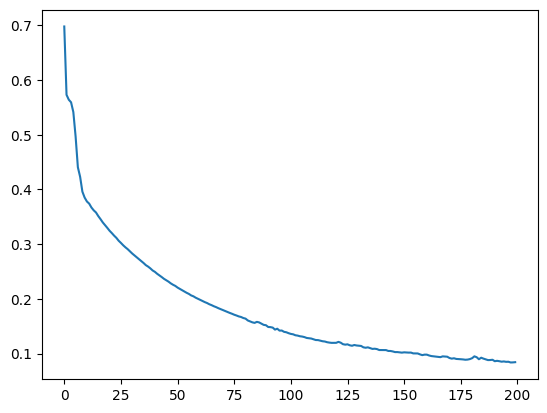

In [9]:
# re_trainer = ssl.ReconstructionError(model, patch_size=patch_size, epochs=epochs, lr=lr)
# re_trainer = ssl.ReconstructionError(model, has_decoder=False, epochs=epochs, lr=lr)
re_trainer = ssl.ReconstructionError(model, epochs=epochs, lr=lr)
e_hat_re, a_hat_re, train_losses_re = re_trainer.train(full_loader, dev=dev)
print(e_hat_re.shape, a_hat_re.shape)

plt.plot(train_losses_re)

### DIP

In [12]:
# dip_trainer = ssl.DIP(model, patch_size=patch_size, epochs=epochs, lr=lr)
dip_trainer = ssl.DIP(model, has_decoder=False, epochs=epochs, lr=lr)
# dip_trainer = ssl.DIP(model, epochs=epochs, lr=lr)
# e_hat_dip, a_hat_dip, train_losses_dip = dip_trainer.train(full_loader)
# print(e_hat_dip.shape, a_hat_dip.shape)

# plt.plot(train_losses_dip)

### Two stages net

In [24]:
# twos_trainer = ssl.TwoStagesNet(model, B, patch_size=patch_size, epochs=epochs, lr=lr)
twos_trainer = ssl.TwoStagesNet(model, B, has_decoder=False, epochs=epochs, lr=lr)
# twos_trainer = ssl.TwoStagesNet(model, B, epochs=epochs, lr=lr)
# e_hat_twos, a_hat_twos, train_losses_twos = twos_trainer.train(full_loader)
# print(e_hat_twos.shape, a_hat_twos.shape)

# plt.plot(train_losses_twos)

### Testing learned model:

<class 'numpy.float32'> 0.5583287


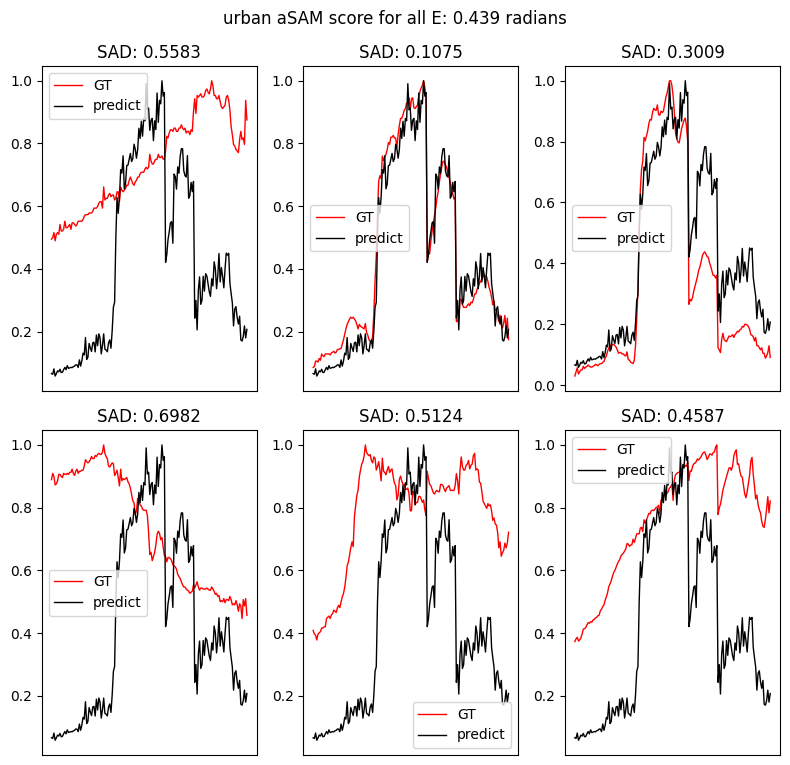

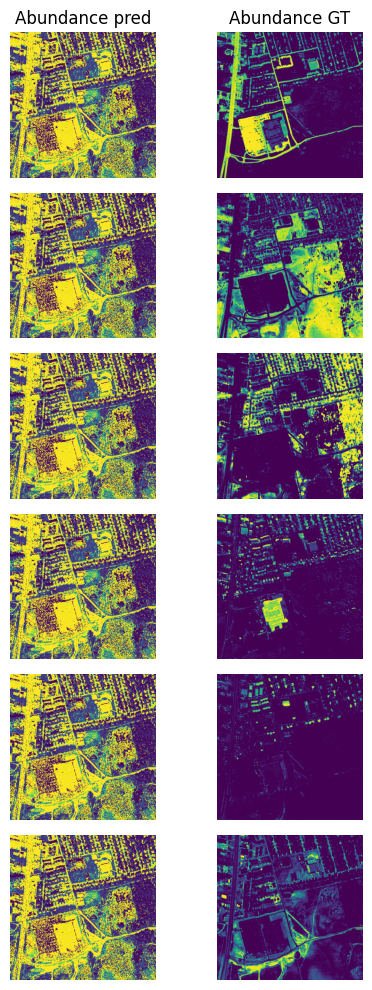

(array([0.31347895, 0.35079256, 0.54061455, 0.4041307 , 0.4202395 ,
        0.2969588 , 0.38770247], dtype=float32),
 array([0.55832869, 0.10745136, 0.30093858, 0.6981647 , 0.51242959,
        0.45874161, 0.43934246]))

In [ ]:
import math
model.load_state_dict(torch.load(f"models/{model.__class__.__name__}_{twos_trainer.__class__.__name__}_{dataset}_lr_{lr}.pt")["model_state_dict"], strict=False)

# Y = torch.tensor(data["Y"])
# Y = Y.to(torch.float32)[:, :patch_size**2]

Y, e_gt, a_gt = next(iter(full_loader))[0][0], next(iter(full_loader))[1][0], next(iter(full_loader))[2][0]
# A_hat = []
# Y = Y_init.reshape(Y_init.shape[0], int(Y_init.shape[1]**0.5), int(Y_init.shape[1]**0.5))
# Y = Y[:, :(Y.shape[1]//patch_size)*patch_size, :(Y.shape[1]//patch_size)*patch_size]
# Y = Y.reshape(Y.shape[0], Y.shape[2]**2)

# a_gt = a_gt.reshape(a_gt.shape[0], int(a_gt.shape[1]**0.5), int(a_gt.shape[1]**0.5))
# a_gt = a_gt[:,:(a_gt.shape[1]//patch_size)*patch_size,:(a_gt.shape[1]//patch_size)*patch_size]
# a_gt = a_gt.reshape(a_gt.shape[0], a_gt.shape[1]**2)
# k = int((Y.shape[1]**0.5)//patch_size)
# Y = Y.reshape(Y.shape[0], int(Y.shape[1]**0.5), int(Y.shape[1]**0.5))
# s = k*patch_size
# Y = Y[:, :s, :s]
# Y = Y.reshape(Y.shape[0], s**2)

# k = math.isqrt(Y.shape[1])//patch_size
# Y = Y[:, :(k*patch_size)**2]

# a_gt = a_gt.reshape(a_gt.shape[0], int(a_gt.shape[1]**0.5), int(a_gt.shape[1]**0.5))
# a_gt = a_gt[:, :s, :s]
# a_gt = a_gt.reshape(a_gt.shape[0], s**2)
# a_gt = a_gt[:, :(k*patch_size)**2]

e_hat, a_hat, y_hat = model.forward(Y)
# e_hat = extractor.normalize_endmembers(e_hat)

if e_hat.dim() == 3:
    e_hat = e_hat.squeeze(0)

a_hat, _ = utils.oneD_to_2d(a_hat)
a_gt, _ = utils.oneD_to_2d(a_gt)
# print(a_hat.shape)
# plt.imshow(a_gt[0,:,:].detach().cpu())

utils.compute_metrics_and_plot(e_hat, e_gt, a_hat, a_gt, dataset)
# A_hat = torch.cat(A_hat, dim=1)